In [1]:
# Process 1: Import Libraries

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Process 2: Download NLTK Data

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# Process 3: Load Dataset

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


In [4]:
train_df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

In [5]:
test_df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

In [6]:
# Process 4: Combine Title + Description

train_df["text"] = train_df["Title"] + " " + train_df["Description"]
test_df["text"] = test_df["Title"] + " " + test_df["Description"]

In [7]:
# Process 5: NLP Preprocessing

stop_words = stopwords.words('english')
lemma = WordNetLemmatizer()

clean_train = []
clean_test = []

# Train data
for text in train_df["text"]:
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    words = [lemma.lemmatize(w) for w in words]
    
    clean_train.append(" ".join(words))

train_df["clean_text"] = clean_train


# Test data
for text in test_df["text"]:
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    words = [lemma.lemmatize(w) for w in words]
    
    clean_test.append(" ".join(words))

test_df["clean_text"] = clean_test

In [8]:
# Process 6: Split features and labels

X_train = train_df["clean_text"]
y_train = train_df["Class Index"]

X_test = test_df["clean_text"]
y_test = test_df["Class Index"]

In [9]:
# Process 7: TF-IDF

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [10]:
#Process 8: Train Models

In [11]:
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

MultinomialNB()

In [12]:
nb_pred = nb.predict(X_test_vec)

In [13]:
nb_acc = accuracy_score(y_test, nb_pred)
print("NB Accuracy:", nb_acc)

NB Accuracy: 0.8905263157894737


In [14]:
print("\nNaive Bayes:\n", classification_report(y_test, nb_pred))


Naive Bayes:
               precision    recall  f1-score   support

           1       0.90      0.89      0.89      1900
           2       0.94      0.97      0.96      1900
           3       0.86      0.84      0.85      1900
           4       0.86      0.86      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [15]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_vec, y_train)

LogisticRegression(max_iter=200)

In [21]:
lr_pred = lr.predict(X_test_vec)

In [22]:
lr_acc = accuracy_score(y_test, lr_pred)
print("LR Accuracy:", lr_acc)

LR Accuracy: 0.9073684210526316


In [23]:
print("\nLogistic Regression:\n", classification_report(y_test, lr_pred))


Logistic Regression:
               precision    recall  f1-score   support

           1       0.92      0.90      0.91      1900
           2       0.95      0.98      0.96      1900
           3       0.88      0.87      0.87      1900
           4       0.88      0.88      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



In [19]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_vec, y_train)

RandomForestClassifier()

In [24]:
rf_pred = rf.predict(X_test_vec)

In [25]:
rf_acc = accuracy_score(y_test, rf_pred)
print("RF Accuracy:", rf_acc)

RF Accuracy: 0.8856578947368421


In [26]:
print("\nRandom Forest:\n", classification_report(y_test, rf_pred))


Random Forest:
               precision    recall  f1-score   support

           1       0.90      0.89      0.89      1900
           2       0.92      0.96      0.94      1900
           3       0.86      0.85      0.85      1900
           4       0.86      0.85      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [27]:
# Process 9: Confusion Matrix

print("NB CM:\n", confusion_matrix(y_test, nb_pred))
print("\nLR CM:\n", confusion_matrix(y_test, lr_pred))
print("\nRF CM:\n", confusion_matrix(y_test, rf_pred))

NB CM:
 [[1687   68   98   47]
 [  29 1843   14   14]
 [  82   20 1603  195]
 [  81   27  157 1635]]

LR CM:
 [[1713   59   75   53]
 [  18 1856   12   14]
 [  64   21 1655  160]
 [  59   23  146 1672]]

RF CM:
 [[1684   85   77   54]
 [  32 1831   21   16]
 [  74   37 1608  181]
 [  81   43  168 1608]]


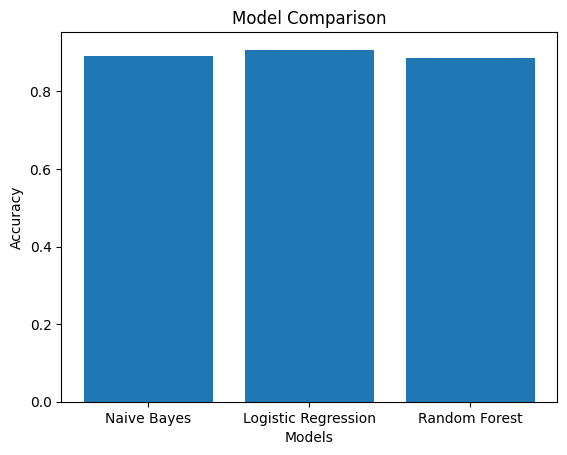

In [28]:
# Process 10: Accuracy Comparison Plot

models = ["Naive Bayes", "Logistic Regression", "Random Forest"]
accuracies = [nb_acc, lr_acc, rf_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()